# Clustering Analysis

Below I will try to understand whether there is a natural grouping structure among customers and explain the process itself as logical as possible.
Instead of prediction, my goal today is exploring the given data, mainly I want to see if customers can be segmented into coherent profiles or not.

I will use four different clustering models:
- K-Means
- DBSCAN
- Gaussian Mixture Model
- Hierarchical Clustering

All of them should operate on the same processed feature space, so the comparison will be fair enough.

# Imports

There are the libraries I will be using for my task.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Loading the dataset

I start by loading the CSV file aka my dataset.
At this point I just want to inspect the structure: columns, types, and missing values.

In [53]:
df = pd.read_csv("../Datasets/Clustering1/Test.csv")

df.head()

,id,customer_age,job_type,marital,education,default,balance,housing_loan,personal_loan,communication_type,day_of_month,month,last_contact_duration,num_contacts_in_campaign,days_since_prev_campaign_contact,num_contacts_prev_campaign,prev_campaign_outcome
0,id_17231,55.0,retired,married,tertiary,no,7136.0,no,no,cellular,13,aug,90.0,2.0,NaN,0,unknown
1,id_34508,24.0,blue-collar,single,secondary,no,179.0,yes,no,cellular,18,may,63.0,2.0,NaN,0,unknown
2,id_44504,46.0,technician,divorced,secondary,no,143.0,no,no,cellular,8,jul,208.0,1.0,NaN,0,unknown
3,id_174,56.0,housemaid,single,unknown,no,6023.0,no,no,unknown,6,jun,34.0,1.0,NaN,0,unknown
4,id_2115,62.0,retired,married,secondary,no,2913.0,no,no,cellular,12,apr,127.0,1.0,188.0,1,success


# Cleaning dataset and selecting necessary features

The `id` column will be removed since it doesn't really carry any semantic meaning. If I will include it, then it would inject artificial distances between the observations.
At this point, clustering is based entirely on similarity, so any meaningless columns would just harm the profiles aka groups.

In [54]:
df = df.drop(columns=["id"])

# Separating numerical and categorical features

Well distance based models cannot operate directly on raw categorical variables, that's why I should split the dataset and apply a one-hot encoding.

In [55]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Feature scaling

All models I use depend on Euclidean distance.
If features are not scaled, then the one with the largest variance dominates everything.
Standardization puts all the features on the same scale.
I as well dropped all NaN values safely, because some imputation methods can actually influence the final PCA results. You can also fill the values with an expected value, but again, dropping them it's safer.

In [56]:
df_encoded = df_encoded.replace([np.inf, -np.inf], np.nan)
df_encoded = df_encoded.dropna()

In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

# Dimensionality reduction with PCA

The encoded feature space is very high dimensional.
That where PCA comes in handy. I will use it to:
- reduce noise,
- improve visualization,
- make density-based methods more stable.

Yet I should I keep enough components to preserve most variance.

In [58]:
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_.sum()

np.float64(0.911877136286119)

# K-Means clustering

K-Means assumes spherical clusters with similar variance, which is reasonable after applying PCA and feature scaling. I set the number of clusters to k = 5 as a balanced segmentation level. Choosing fewer clusters (k = 4) would risk under-segmentation by merging distinct customer groups, while a higher value (k = 6 or more) could lead to over-segmentation and reduced interpretability. At this point I think k = 5 will provide a compromise between granularity and clarity.

In [59]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

# K-Means centroid visualization (PCA in 2D)

This plot will show:
- each point as a customer,
- each centroid as the average profile of a cluster.

If centroids overlap heavily, like really heavily, then K-Means should be forcing structures that don't exist.

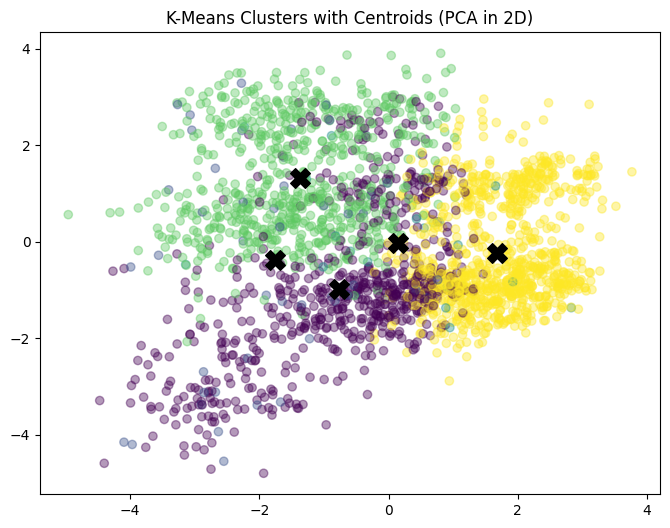

In [60]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_pca)
centroids_2d = pca_2d.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=kmeans_labels, alpha=0.4)
plt.scatter(centroids_2d[:,0], centroids_2d[:,1], c="black", s=200, marker="X")
plt.title("K-Means Clusters with Centroids (PCA in 2D)")
plt.show()

# K-Means Clustering Visualization (k = 5)

The following plot represents the K-Means clustering results projected onto a 2D PCA space. 
Since K-Means assumes spherical clusters with similar variance, as I mentioned before, I will now expect relatively compact and well-separated groups after dimensionality reduction.
The visualization allows me to observe the spatial distribution of clusters and evaluate their separation.

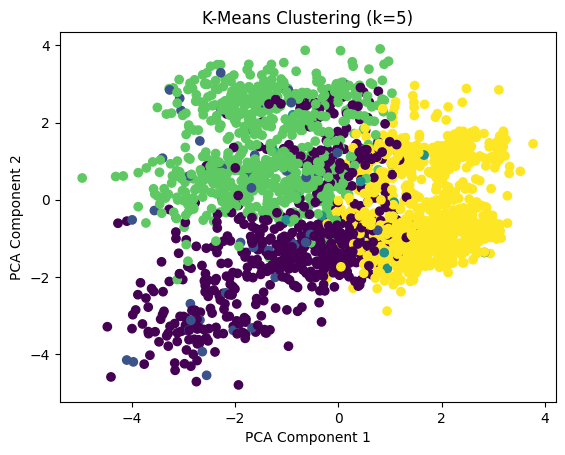

In [61]:
# PCA to 2D for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_pca)

# Fit KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

# Plot
plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_labels)
plt.title("K-Means Clustering (k=5)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# DBSCAN Clustering Visualization

Unlike K-Means and GMM, DBSCAN does not require specifying the number of clusters beforehand. The visualization will highlight detected clusters and potential noise points.

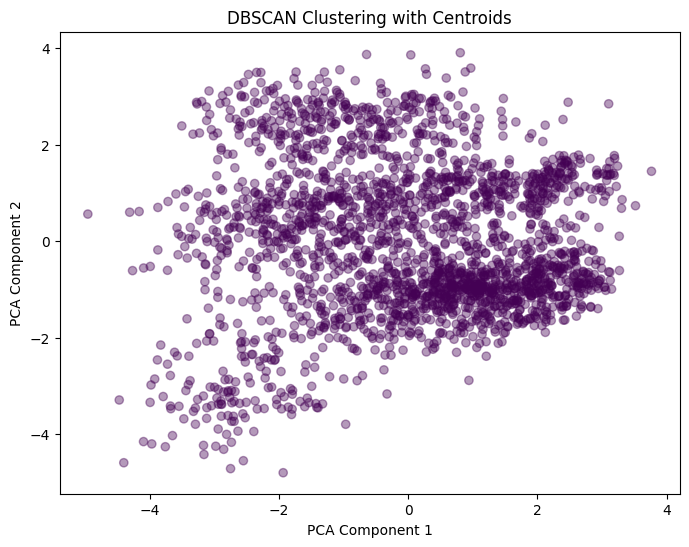

In [62]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=dbscan_labels, alpha=0.4)
for label in set(dbscan_labels):
    if label != -1:
        cluster_points = X_2d[dbscan_labels == label]
        centroid = cluster_points.mean(axis=0)
        plt.scatter(centroid[0], centroid[1], c="black", s=200, marker="X", edgecolors="white")
plt.title("DBSCAN Clustering with Centroids")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


# Gaussian Mixture Model

GMM assumes data is generated by overlapping Gaussian distributions.
Unlike K-Means, it allows soft assignments and elliptical shapes.

In [63]:
gmm = GaussianMixture(n_components=5, random_state=42)
gmm_labels = gmm.fit_predict(X_pca)

# Gaussian Mixture Model Visualization

The 2D PCA projection below illustrates how GMM assigns data points 
to probabilistic components.

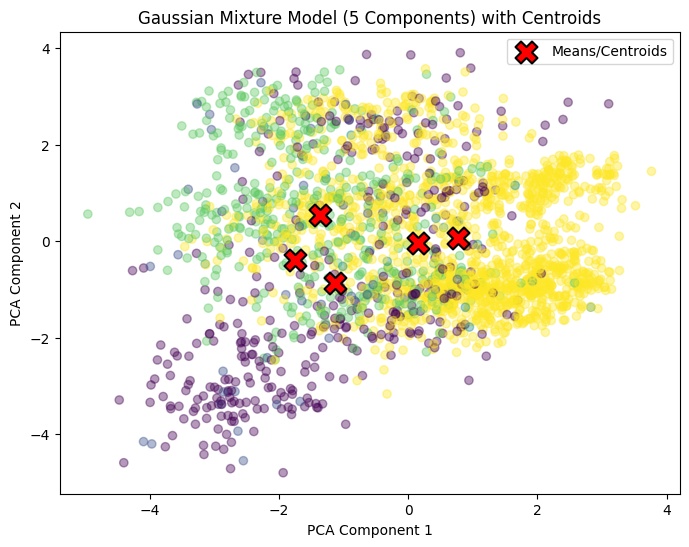

In [64]:
gmm = GaussianMixture(n_components=5, random_state=42)
gmm_labels = gmm.fit_predict(X_pca)
gmm_centroids_2d = pca_2d.transform(gmm.means_)
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=gmm_labels, alpha=0.4, cmap='viridis')
plt.scatter(gmm_centroids_2d[:, 0], gmm_centroids_2d[:, 1], 
            c="red", s=250, marker="X", edgecolors="black", 
            linewidths=1.5, zorder=5, label="Means/Centroids")
plt.title("Gaussian Mixture Model (5 Components) with Centroids")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()


## Hierarchical Clustering

Hierarchical clustering reveals nested structures.
The dendrogram shows how clusters merge at different distances.

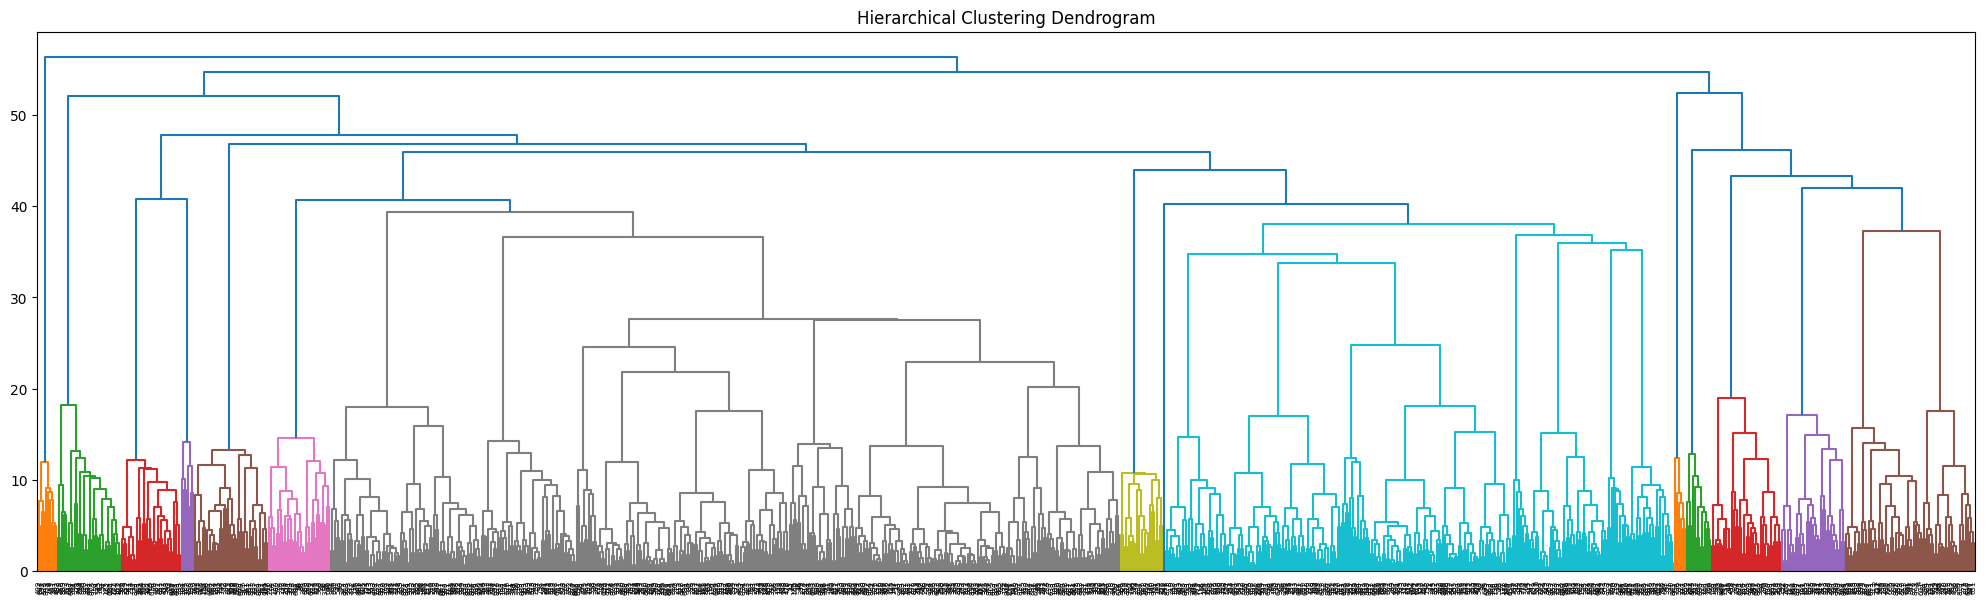

In [65]:
Z = linkage(X_pca[:1000], method="ward")

plt.figure(figsize=(25,7))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

hc_labels = fcluster(Z, t=5, criterion="maxclust")

# Model evaluation

Since clustering is unsupervised, I wil have to use internal metrics.
They measure cohesion and separation, but not the correctness.

In [66]:
def evaluate(X, labels, name):
    mask = labels != -1
    
    # Check if DBSCAN produced valid clusters
    unique_clusters = set(labels[mask])
    
    if len(unique_clusters) < 2:
        return name, None, None
    
    sil = silhouette_score(X[mask], labels[mask])
    db = davies_bouldin_score(X[mask], labels[mask])
    
    return name, sil, db

results = pd.DataFrame([
    evaluate(X_pca, kmeans_labels, "KMeans"),
    evaluate(X_pca, dbscan_labels, "DBSCAN"),
    evaluate(X_pca, gmm_labels, "GMM"),
    evaluate(X_pca[:1000], hc_labels, "Hierarchical")
], columns=["Model", "Silhouette", "Davies-Bouldin"])

results

,Model,Silhouette,Davies-Bouldin
0,KMeans,0.077126,2.694014
1,DBSCAN,NaN,NaN
2,GMM,0.115545,3.277232
3,Hierarchical,0.163966,2.022826


# Final Conclusion

On this dataset:

> K-Means: identifies basic structural patterns but imposes spherical cluster boundaries, which may oversimplify the underlying relationships between customers.

> DBSCAN: fails to detect stable density-based clusters, labeling a significant portion of the observations as noise. This suggests that the dataset does not exhibit strong density-separated 
regions.

> Gaussian Mixture Model: captures overlapping cluster structures and allows softer boundaries between segments, reflecting gradual transitions between customer profiles.

> Hierarchical Clustering: achieves the best internal validation performance (highest Silhouette Score and lowest Davies–Bouldin Index), indicating comparatively better separation and cohesion among clusters.

Overall, although Hierarchical clustering performs best numerically, all models produce relatively low Silhouette Scores. This indicates that the dataset does not contain strongly separated natural groups. Instead of forming sharply defined segments, the data behaves more like a continuum of overlapping customer characteristics, where boundaries between profiles are gradual rather than distinct.